# Plotting of data

In [1]:
import re
import pickle
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import function_definitions as field_funcs
import OCP_construction_functions as OCP_funcs
def get_floats_from_filename(filename):
    return re.findall(r"[+-]? *(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?", filename)


def create_dict_for_folder(folderdir):
    file_names_in_folder = os.listdir(folderdir)
    stepsize_filename_dict = dict()
    for x in file_names_in_folder:
        stepsize_filename_dict[x] = [float(y)  for y in get_floats_from_filename(x)] #assume fix order a,b,gamma,h
    return stepsize_filename_dict    
    

In [2]:
base_folder_dir = 'data/low_thrust/polar_variables'
def get_data_from_folder(foldername):
    folder_names = os.listdir(foldername+'/')
    dict_of_folders_with_files = dict()
    for x in folder_names:
        if x != '.DS_Store':
            dict_of_folders_with_files[x] = create_dict_for_folder(foldername+'/' +x)
    data_dict = dict()
    for x in dict_of_folders_with_files.keys():
        for y in dict_of_folders_with_files[x].keys():
            if y == '.DS_Store':
                continue

            filename = foldername+"/"+x + "/"+y
            with open(filename, 'rb') as files:
                data_dict[y] = [pickle.load(files) ,dict_of_folders_with_files[x][y]]
    return data_dict            

base_folder_dir_test = base_folder_dir
base_foldername = base_folder_dir_test 
data=get_data_from_folder(base_foldername)



In [3]:
use_data = data['data_a=0.5g=1N=350.pkl'][0]

qd = use_data['q_d_new']
vqd = use_data['v_y_d_new'][:,:2]
vkappad = use_data['v_y_d_new'][:,2:]
kappad = use_data['lambda_d_new']
lamqd = use_data['lambda_q_standard']
lamvd = use_data['lambda_v_standard']
ud_new = use_data['u_d_new']

continuous_eq = OCP_funcs.Direct_continuous_generator(use_data["parameters"],f_func=field_funcs.f_vec_polar,rho_func=field_funcs.rho_vec_polar,running_cost_func=field_funcs.running_cost_polar,mayer_func=field_funcs.mayer_term_polar,g_func=field_funcs.g_mat_polar)
discrete_equations = OCP_funcs.discrete_standard_direct_eq_generator(continuous_eq)


# Generating the reference via the indirect solution

In [ ]:
ref_name = 'data/low_thrust/polar_variables/reference/reference_polar.pkl'

with open(ref_name, 'rb') as filetmp:
    ref_data = pickle.load(filetmp)

import scipy
import sympy

t_ref = np.array(ref_data["time"])





cs_q_ref =  scipy.interpolate.CubicSpline(t_ref, np.array([ref_data["state_r"],ref_data["state_phi"]]).transpose())
cs_lambda_q_ref =  scipy.interpolate.CubicSpline(t_ref, np.array([ref_data["costate_r"],ref_data["costate_phi"]]).transpose())
cs_lambda_v_ref =  scipy.interpolate.CubicSpline(t_ref, np.array([ref_data["costate_vr"],ref_data["costate_vphi"]]).transpose())
cs_u_d_ref =  scipy.interpolate.CubicSpline(t_ref, np.array(ref_data["control"]).reshape((len(t_ref),1)))
cs_v_q_ref = scipy.interpolate.CubicSpline(t_ref, np.array([ref_data["state_vr"],ref_data["state_vphi"]]).transpose())

kappa_ref = np.array([continuous_eq.kappa_calc(tmplamv) for tmplamv in cs_lambda_v_ref(t_ref)])
cs_kappa_ref = scipy.interpolate.CubicSpline(t_ref, kappa_ref)

vkappa_vars = [continuous_eq.q,continuous_eq.vq,continuous_eq.lamq,continuous_eq.lamv,continuous_eq.u]
vkappa_vars = sympy.flatten(vkappa_vars)
lambdified_vkappa = sympy.lambdify(vkappa_vars,continuous_eq.v_kappa_calc(continuous_eq.q,continuous_eq.vq,continuous_eq.lamq,continuous_eq.lamv,continuous_eq.u))
v_kappa_ref = np.array([lambdified_vkappa(*tmpq,*tmpvq,*tmplamq,*tmplamv,*tmpu).flatten() for tmpq,tmpvq,tmplamq,tmplamv,tmpu in zip(cs_q_ref(t_ref),cs_v_q_ref(t_ref),cs_lambda_q_ref(t_ref),cs_lambda_v_ref(t_ref),cs_u_d_ref(t_ref).reshape((len(t_ref),1)))])


cs_v_kappa_ref = scipy.interpolate.CubicSpline(t_ref, v_kappa_ref)
cs_v_y_d_ref = lambda x: np.append(cs_v_q_ref(x).transpose() , cs_v_kappa_ref(x).transpose() ,0).transpose()
cs_lambda_d_new_ref =  cs_lambda_v_ref
cs_H_d_new_ref =  scipy.interpolate.CubicSpline(t_ref, -np.array(ref_data["Hamiltonian"]))


import sympy


#Polar conserved quantity calc
p_y_calc = continuous_eq.p_y().subs([[tmp1,tmp2] for tmp1,tmp2 in zip(continuous_eq.lamq,continuous_eq.kappa)]).subs([[tmp1,tmp2] for tmp1,tmp2 in zip(continuous_eq.vlam,continuous_eq.vkappa)])

p_y_lambdified = sympy.lambdify(sympy.flatten([continuous_eq.q,continuous_eq.vq,continuous_eq.kappa,continuous_eq.vkappa,continuous_eq.u]),
                                p_y_calc)

p_ref = []
for tmpq,tmpkappa,tmpvy,tmpu in zip(cs_q_ref(t_ref),cs_kappa_ref(t_ref),cs_v_y_d_ref(t_ref),cs_u_d_ref(t_ref)):
    p_ref.append(np.array(p_y_lambdified(*tmpq,*tmpvy[:2],*tmpkappa,*(tmpvy[2:]),*tmpu),float).flatten())
p_ref = np.array(p_ref)    
I_new_ref = p_ref.T[1]

cs_I_d_new_ref =  scipy.interpolate.CubicSpline(t_ref, I_new_ref)


ref_curves = {"q_d_new":cs_q_ref, "lambda_q_standard":cs_lambda_q_ref, "lambda_v_standard":cs_lambda_v_ref
              ,"u_d_new": cs_u_d_ref, "v_y_d_new":cs_v_y_d_ref,"lambda_d_new":cs_kappa_ref
              , "I_d_new":cs_I_d_new_ref, "H_control_new":cs_H_d_new_ref,'lambda_q_d_new':cs_lambda_q_ref}

def calculate_error(vec, ref_vec):
    error_vec = vec-ref_vec
    if not isinstance(vec,np.ndarray):
        error = error_vec*(error_vec)
    else:
        error = error_vec.dot(error_vec)
    return np.sqrt(error)
    
def calculate_max_error_curve(vec_curve, ref_curve):
    errors = []
    for vec,ref_vec in zip(vec_curve,ref_curve):
        errors.append(calculate_error(vec,ref_vec))
    return max(errors)


In [5]:
def polar_to_cartesian_sympy(q_polar):
    r,phi = q_polar
    q_cartesian = sympy.Matrix([r * sympy.cos(phi), r * sympy.sin(phi)])
    return q_cartesian

def polar_to_cartesian_velocity(q_polar,v_polar):
    jacobian = polar_to_cartesian_sympy(q_polar).jacobian(q_polar)
    v_cartesian = jacobian@ v_polar
    return v_cartesian

def polar_to_cartesian_lambda_q(q_polar,v_polar,lamq_polar,lamv_polar):
    jacobianT = polar_to_cartesian_sympy(q_polar).jacobian(q_polar).T
    jacobianinv = sympy.inv_quick(jacobianT)

    return jacobianinv @ lamq_polar

def polar_to_cartesian_lambda_v(q_polar,v_polar,lamq_polar,lamv_polar):
    base_jacobian = polar_to_cartesian_sympy(q_polar).jacobian(q_polar)
    G_v = base_jacobian@ v_polar
    jacobianT = G_v.jacobian(v_polar).T
    jacobianinv = sympy.inv_quick(jacobianT)

    return jacobianinv @ lamv_polar

# technically should use r,phi, but for ease just use cartesian variables and reinterpret
polar_to_cartesian_trafo_q = polar_to_cartesian_sympy(continuous_eq.q)
polar_to_cartesian_trafo_vq = polar_to_cartesian_velocity(continuous_eq.q,continuous_eq.vq)
polar_to_cartesian_trafo_lamq = polar_to_cartesian_lambda_q(continuous_eq.q,continuous_eq.vq,continuous_eq.lamq,continuous_eq.lamv)
polar_to_cartesian_trafo_lamv = polar_to_cartesian_lambda_v(continuous_eq.q,continuous_eq.vq,continuous_eq.lamq,continuous_eq.lamv)

lambdified_q_p_to_c = sympy.lambdify(continuous_eq.q,polar_to_cartesian_trafo_q)
lambdified_vq_p_to_c = sympy.lambdify(sympy.flatten(continuous_eq.q)+sympy.flatten(continuous_eq.vq),polar_to_cartesian_trafo_vq)
lambdified_lamq_p_to_c = sympy.lambdify(sympy.flatten(continuous_eq.q)+sympy.flatten(continuous_eq.vq)+sympy.flatten(continuous_eq.lamq)+sympy.flatten(continuous_eq.lamv),polar_to_cartesian_trafo_lamq)
lambdified_lamv_p_to_c = sympy.lambdify(sympy.flatten(continuous_eq.q)+sympy.flatten(continuous_eq.vq)+sympy.flatten(continuous_eq.lamq)+sympy.flatten(continuous_eq.lamv),polar_to_cartesian_trafo_lamv)




In [6]:
qd_cart = []
vqd_cart = []
lamqd_cart = []
lamvd_cart = []

for tmpq,tmpv,tmplamq,tmplamv in zip(qd,vqd,lamqd,lamvd):
    qd_cart.append(lambdified_q_p_to_c(*tmpq).flatten())
    vqd_cart.append(lambdified_vq_p_to_c(*tmpq,*tmpv).flatten())
    lamqd_cart.append(lambdified_lamq_p_to_c(*tmpq,*tmpv,*tmplamq,*tmplamv).flatten())
    lamvd_cart.append(lambdified_lamv_p_to_c(*tmpq,*tmpv,*tmplamq,*tmplamv).flatten())
    
qd_cart = np.array(qd_cart)
vqd_cart = np.array(vqd_cart)
lamqd_cart = np.array(lamqd_cart)
lamvd_cart = np.array(lamvd_cart)


In [7]:
def calc_lambdaq_from_new_for_postprocessing_data(data,continuous_eq):
    'to calculate the lambda_q from kappa'
    q_d = data['q_d_new']
    vy_d = data['v_y_d_new']
    kappa_d = data['lambda_d_new']
    u_d = data['u_d_new']
    lambda_q_d_new = []
    lamq_calc = sympy.lambdify(sympy.flatten(continuous_eq.q)+sympy.flatten(continuous_eq.vq)+sympy.flatten(continuous_eq.kappa)+sympy.flatten(continuous_eq.vkappa),continuous_eq.lamq_calc(continuous_eq.q,continuous_eq.vq,continuous_eq.kappa,continuous_eq.vkappa))

    for i in range(len(q_d)):
        lambda_q_d_new.append(sympy.flatten(lamq_calc(*q_d[i],*vy_d[i,:2],*kappa_d[i],*vy_d[i,2:])))
    data['lambda_q_d_new'] = np.array(lambda_q_d_new,float)


In [8]:
for tmp_key in data.keys():
    if not 'reference' in tmp_key and not 'comp_times' in tmp_key:
        calc_lambdaq_from_new_for_postprocessing_data(data[tmp_key][0],continuous_eq)

In [9]:
alpha_choice,gamma_choice = 0.5,0.5

N_choices = [100,150,200,250,300,350,400,450,500,550,600]

h_choices = [1.0/tmp for tmp in N_choices]

def get_convergence_data_from_N_vals(data_choice,N_vals,data_dict,alpha,gamma):
    ts = []
    list_chosen_data = []
    for tmp in N_vals:
        file_name_u =  "data_a="+str(alpha)+"g="+str(gamma)+"N="+str(tmp)+".pkl"   
        loaded_dict = data_dict[file_name_u][0]
        ts.append(loaded_dict["parameters"]["times"])
        list_chosen_data.append(loaded_dict[data_choice])
    return ts,list_chosen_data

def get_error_for_approach_keys(approach_key, N_vals, data_dict, alpha,gamma,reference_curve,for_vy_get_q_part=True,skip_end_vals=None):
    times,data_vals = get_convergence_data_from_N_vals(approach_key,N_vals,data_dict,alpha,gamma)
    if "v_y" not in approach_key:
        errors =[calculate_max_error_curve(tmpcurve[skip_end_vals:],reference_curve(tmpt)[skip_end_vals:]) for tmpt,tmpcurve in zip(times,data_vals)]
    else:
        if for_vy_get_q_part:
            errors =[calculate_max_error_curve(tmpcurve[:,:2][skip_end_vals:],reference_curve(tmpt)[skip_end_vals:]) for tmpt,tmpcurve in zip(times,data_vals)]
        else:
            errors =[calculate_max_error_curve(tmpcurve[:,2:][skip_end_vals:],reference_curve(tmpt)[skip_end_vals:]) for tmpt,tmpcurve in zip(times,data_vals)]

    return errors,times



def get_error_data_alpha_gamma(alpha_choice,gamma_choice,data_choice,ref_curves,N_choices):
    new_approach_keys= ['q_d_new','lambda_d_new', 'u_d_new', 'v_y_d_new', 'I_d_new', 'H_control_new','lambda_q_d_new']
    all_errors_dict = dict()
    # new approach error calculation
    for i in [0,1,2,4,5,6]:
        all_errors_dict[new_approach_keys[i]],_ = get_error_for_approach_keys(new_approach_keys[i],N_choices,data_choice,alpha_choice,gamma_choice,ref_curves[new_approach_keys[i]],skip_end_vals=1)
    i_choice = 3
    vq_ref_eval = lambda x : ref_curves[new_approach_keys[i_choice]](x)[:,:2]
    all_errors_dict["v_q_new"],_ = get_error_for_approach_keys(new_approach_keys[i_choice],N_choices,data_choice,alpha_choice,gamma_choice,vq_ref_eval,True,skip_end_vals=1)
    vlam_ref_eval = lambda x : ref_curves[new_approach_keys[i_choice]](x)[:,2:]
    all_errors_dict["v_lambda_new"],times = get_error_for_approach_keys(new_approach_keys[i_choice],N_choices,data_choice,alpha_choice,gamma_choice,vlam_ref_eval,False,skip_end_vals=1)

    ###########################
    ###########################
    # standard approach error calc - though not clear what ref solution should be until we use the proper reference solution
    ###########################
    ###########################
    standard_approach_keys= [ 'q_d_standard', 'lambda_v_standard', 'lambda_q_standard','vq_d_standard', 'u_d_standard', 'I_d_standard', 'H_pontry_standard']
    standard_ref_keys = ['q_d_new', 'lambda_v_standard','lambda_q_standard','v_y_d_new', 'u_d_new','I_d_new','H_control_new']
    all_errors_dict_standard=dict()
    for i in [0,1,2,4,5]:
        all_errors_dict_standard[standard_approach_keys[i]],_ = get_error_for_approach_keys(standard_approach_keys[i],N_choices,data_choice,alpha_choice,gamma_choice,ref_curves[standard_ref_keys[i]],skip_end_vals=1)

    all_errors_dict_standard[standard_approach_keys[3]],_ = get_error_for_approach_keys(standard_approach_keys[3],N_choices,data_choice,alpha_choice,gamma_choice,vq_ref_eval,skip_end_vals=1)

    ref_H_curve = lambda x: -ref_curves["H_control_new"](x)
    all_errors_dict_standard[standard_approach_keys[-1]],_ = get_error_for_approach_keys(standard_approach_keys[-1],N_choices,data_choice,alpha_choice,gamma_choice,ref_H_curve,skip_end_vals=1)
    return all_errors_dict,all_errors_dict_standard,times


data_dicts_a1g0 = get_error_data_alpha_gamma(1,1,data,ref_curves,N_choices)
data_dicts_a1g1 = get_error_data_alpha_gamma(0.5,1,data,ref_curves,N_choices)
data_dicts_a05g05 = get_error_data_alpha_gamma(1,0.5,data,ref_curves,N_choices)



In [10]:
def model_curve(x,a,b):
    return a*x**b
def fit_to_data(x_vals, data):
    fit_result = scipy.optimize.curve_fit(model_curve,x_vals,data)
    return fit_result

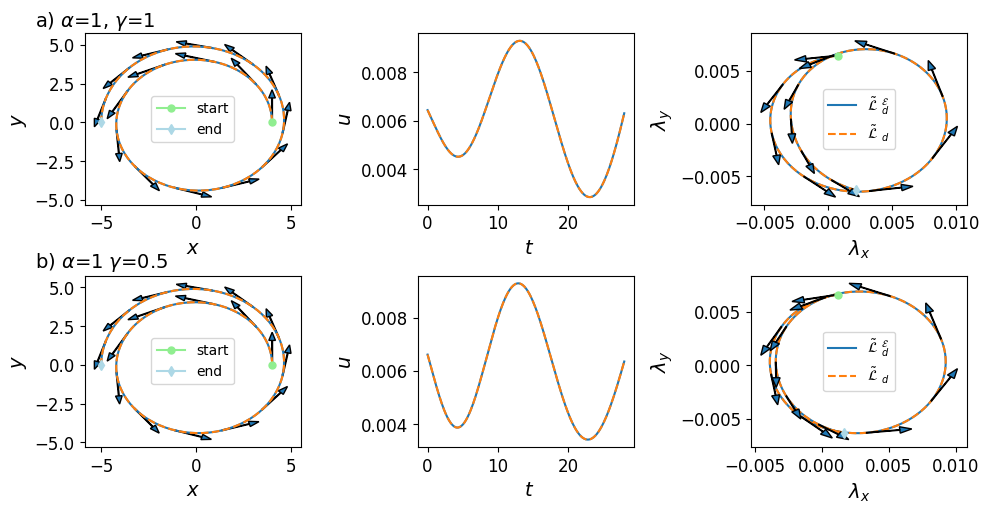

In [11]:
def plot_curve_with_velocity_arrows(axs_obj,curve_plot,v_plot,spacing=5,furtherparamsdict={'length_includes_head':True,'head_width':0.1}): 
        for i in range(len(v_plot)):
                if i % spacing ==0:
                        axs_obj.arrow(curve_plot[i][0],curve_plot[i][1],v_plot[i][0],v_plot[i][1],**furtherparamsdict)

data_vis_2 = data["data_a=1g=0.5N=250.pkl"][0]
data_vis_1 = data["data_a=1g=1N=250.pkl"][0]

labelfont = 14
tickfont = 12

fig, axs = plt.subplots(2, 3,figsize=(10,5))

axs[0,0].plot(data_vis_1['q_d_new_cartesian'].T[0],data_vis_1['q_d_new_cartesian'].T[1],'-')  
axs[0,0].plot(data_vis_1['q_d_new_no_u_cartesian'].T[0],data_vis_1['q_d_new_no_u_cartesian'].T[1],'--')  

axs[0,0].ticklabel_format(style='sci')
axs[0,0].tick_params(labelsize=tickfont)
axs[0,0].set_xlabel(r'$x$',fontsize=labelfont)
axs[0,0].set_ylabel(r'$y$',fontsize=labelfont)
axs[0,1].plot(data_vis_1['parameters']['times'],data_vis_1['u_d_new'],'-')
axs[0,1].plot(data_vis_1['parameters']['times'],data_vis_1['u_d_new_no_u'],'--')
axs[0,1].ticklabel_format(style='sci')
axs[0,2].plot(data_vis_1['lambda_d_new_cart'].T[0],data_vis_1['lambda_d_new_cart'].T[1],'-',label=r'$\tilde{\mathcal{L}}~{}_d^\mathcal{E}$')   
axs[0,2].plot(data_vis_1['lambda_d_new_no_u_cart'].T[0],data_vis_1['lambda_d_new_no_u_cart'].T[1],'--',label=r'$\tilde{\mathcal{L}}~{}_d$')   

axs[0,1].set_xlabel(r" $t$",fontsize=labelfont)
axs[0,1].set_ylabel(r"$u$",fontsize=labelfont)
axs[0,2].set_xlabel(r'$\lambda_x$',fontsize=labelfont)
axs[0,2].set_ylabel(r'$\lambda_y$',fontsize=labelfont)

fig.tight_layout()
fig.text(0.04,0.983,r"a) $\alpha$=1, $\gamma$=1",fontsize=labelfont)



axs[1,0].plot(data_vis_2['q_d_new_cartesian'].T[0],data_vis_2['q_d_new_cartesian'].T[1],'-')  
axs[1,0].plot(data_vis_2['q_d_new_no_u_cartesian'].T[0],data_vis_2['q_d_new_no_u_cartesian'].T[1],'--')  

axs[1,0].ticklabel_format(style='sci')
axs[1,0].tick_params(labelsize=tickfont)
axs[1,0].set_xlabel(r'$x$',fontsize=labelfont)
axs[1,0].set_ylabel(r'$y$',fontsize=labelfont)
axs[1,1].plot(data_vis_2['parameters']['times'],data_vis_2['u_d_new'],'-')
axs[1,1].plot(data_vis_2['parameters']['times'],data_vis_2['u_d_new_no_u'],'--')
axs[1,1].ticklabel_format(style='sci')
axs[1,2].plot(data_vis_2['lambda_d_new_cart'].T[0],data_vis_2['lambda_d_new_cart'].T[1],'-',label=r'$\tilde{\mathcal{L}}~{}_d^\mathcal{E}$')   
axs[1,2].plot(data_vis_2['lambda_d_new_no_u_cart'].T[0],data_vis_2['lambda_d_new_no_u_cart'].T[1],'--',label=r'$\tilde{\mathcal{L}}~{}_d$')   
axs[1,1].set_xlabel(r" $t$",fontsize=labelfont)
axs[1,1].set_ylabel(r"$u$",fontsize=labelfont)  
axs[1,2].set_xlabel(r'$\lambda_x$',fontsize=labelfont)
axs[1,2].set_ylabel(r'$\lambda_y$',fontsize=labelfont)
fig.text(0.04,0.5,r"b) $\alpha$=1 $\gamma$=0.5",fontsize=labelfont)
axs[0,0].tick_params(labelsize=tickfont)
axs[0,1].tick_params(labelsize=tickfont)
axs[0,2].tick_params(labelsize=tickfont)
axs[1,0].tick_params(labelsize=tickfont)
axs[1,1].tick_params(labelsize=tickfont)
axs[1,2].tick_params(labelsize=tickfont)


plot_curve_with_velocity_arrows(axs[0,0],data_vis_1['q_d_new_cartesian'],data_vis_1['v_y_d_new_no_u_cart'][:,:2],15,{'head_width':0.35,'width':0.041})  
plot_curve_with_velocity_arrows(axs[0,2],data_vis_1['lambda_d_new_no_u_cart'],data_vis_1['v_y_d_new_no_u_cart'][:,2:],20,{'head_width':0.0006,'width':0.000051,'zorder':10})  
plot_curve_with_velocity_arrows(axs[1,2],data_vis_2['lambda_d_new_no_u_cart'],data_vis_2['v_y_d_new_no_u_cart'][:,2:],20,{'head_width':0.0006,'width':0.000051,'zorder':10})  
plot_curve_with_velocity_arrows(axs[1,0],data_vis_2['q_d_new_cartesian'],data_vis_2['v_y_d_new_no_u_cart'][:,:2],15,{'head_width':0.35,'width':0.041})  

boundarymarkersize=5
axs[0,0].plot([data_vis_1['q_d_new_cartesian'][0,0]],[data_vis_1['q_d_new_cartesian'][0,1]],marker='o', color='lightgreen',markersize=boundarymarkersize,label='start',zorder=11)
axs[0,0].plot([data_vis_1['q_d_new_cartesian'][-1][0]],[data_vis_1['q_d_new_cartesian'][-1][1]],marker='d', color='lightblue',markersize=boundarymarkersize,label='end',zorder=11)
axs[0,0].legend()
axs[0,2].legend()
axs[0,2].plot([data_vis_1['lambda_d_new_no_u_cart'][0][0]],[data_vis_1['lambda_d_new_no_u_cart'][0][1]],marker='o', color='lightgreen',markersize=boundarymarkersize,label='start',zorder=11)
axs[0,2].plot([data_vis_1['lambda_d_new_no_u_cart'][-1][0]],[data_vis_1['lambda_d_new_no_u_cart'][-1][1]],marker='d', color='lightblue',markersize=boundarymarkersize,label='end',zorder=11)

axs[1,0].plot([data_vis_2['q_d_new_cartesian'][0,0]],[data_vis_2['q_d_new_cartesian'][0,1]],marker='o', color='lightgreen',markersize=boundarymarkersize,label='start',zorder=11)
axs[1,0].plot([data_vis_2['q_d_new_cartesian'][-1][0]],[data_vis_2['q_d_new_cartesian'][-1][1]],marker='d', color='lightblue',markersize=boundarymarkersize,label='end',zorder=11)
axs[1,0].legend()
axs[1,2].legend()
axs[1,2].plot([data_vis_2['lambda_d_new_no_u_cart'][0][0]],[data_vis_2['lambda_d_new_no_u_cart'][0][1]],marker='o', color='lightgreen',markersize=boundarymarkersize,label='start',zorder=11)
axs[1,2].plot([data_vis_2['lambda_d_new_no_u_cart'][-1][0]],[data_vis_2['lambda_d_new_no_u_cart'][-1][1]],marker='d', color='lightblue',markersize=boundarymarkersize,label='end',zorder=11)


plt.tight_layout()
# plt.savefig('Examples_fig_1.pdf',bbox_inches='tight')


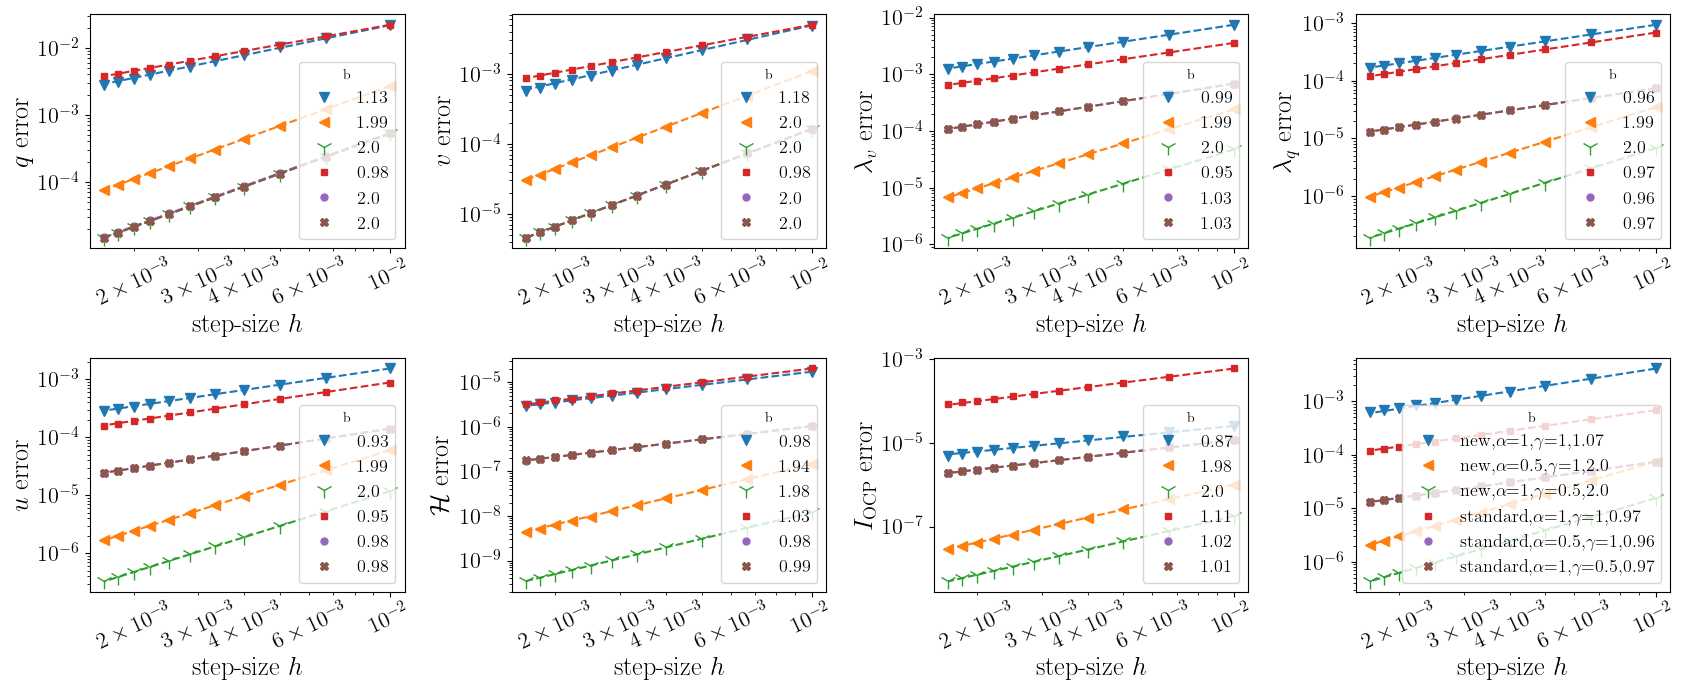

In [12]:
labelfont = 19
tickfont = 16
legendfont = 13

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "amsmath"
})

def create_error_plot(x_vals,error_data,labeltxt,axs_obj,markerstyle='x',markersize=8,colorstyle='blue'):
    fit_params = fit_to_data(x_vals,error_data)
    axs_obj.plot(x_vals,error_data,markerstyle,label=labeltxt + str(np.round(fit_params[0][1],2)),markersize=markersize,color=colorstyle)
    axs_obj.plot(x_vals,model_curve(x_vals,*fit_params[0]),'--',color=colorstyle)

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','C4','C5']
symbols = ['v','<','1','s','o','X']
symbolsizes = [7,7,12,5,5,6]
fig=plt.figure(figsize=(17, 7))
ax1 = plt.subplot(2,4,1)
ax2 = plt.subplot(2,4,2)
ax3 = plt.subplot(2,4,3)
ax4 = plt.subplot(2,4,4)
ax5 = plt.subplot(2,4,5)
ax6 = plt.subplot(2,4,6)
ax7 = plt.subplot(2,4,7)
ax8 = plt.subplot(2,4,8)
axs = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8]


chosen_ax = axs[0]
create_error_plot(h_choices,data_dicts_a1g0[0]["q_d_new"],"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["q_d_new"],"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["q_d_new"],"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["q_d_standard"],"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["q_d_standard"],"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["q_d_standard"],"",chosen_ax,symbols[5],symbolsizes[5],colors[5])

chosen_ax.set_ylabel(r'$q$ error',fontsize=labelfont)


chosen_ax =axs[1]
create_error_plot(h_choices,data_dicts_a1g0[0]["v_q_new"],"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["v_q_new"],"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["v_q_new"],"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["vq_d_standard"],"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["vq_d_standard"],"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["vq_d_standard"],"",chosen_ax,symbols[5],symbolsizes[5],colors[5])

chosen_ax.set_ylabel(r'$v$ error',fontsize=labelfont)

chosen_ax =axs[2]
create_error_plot(h_choices,data_dicts_a1g0[0]["lambda_d_new"],"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["lambda_d_new"],"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["lambda_d_new"],"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["lambda_v_standard"],"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["lambda_v_standard"],"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["lambda_v_standard"],"",chosen_ax,symbols[5],symbolsizes[5],colors[5])

chosen_ax.set_ylabel(r'$\lambda_v$ error',fontsize=labelfont)

chosen_ax =axs[3]
create_error_plot(h_choices,data_dicts_a1g0[0]["lambda_q_d_new"],r"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["lambda_q_d_new"],r"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["lambda_q_d_new"],r"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["lambda_q_standard"],r"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["lambda_q_standard"],r"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["lambda_q_standard"],r"",chosen_ax,symbols[5],symbolsizes[5],colors[5])

chosen_ax.set_ylabel(r'$\lambda_q$ error',fontsize=labelfont)


chosen_ax = axs[4]
create_error_plot(h_choices,data_dicts_a1g0[0]["u_d_new"],"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["u_d_new"],"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["u_d_new"],"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["u_d_standard"],"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["u_d_standard"],"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["u_d_standard"],"",chosen_ax,symbols[5],symbolsizes[5],colors[5])

chosen_ax.set_ylabel(r'$u$ error',fontsize=labelfont)

chosen_ax = axs[5]
create_error_plot(h_choices,data_dicts_a1g0[0]["H_control_new"],"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["H_control_new"],"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["H_control_new"],"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["H_pontry_standard"],"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["H_pontry_standard"],"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["H_pontry_standard"],"",chosen_ax,symbols[5],symbolsizes[5],colors[5])

chosen_ax.set_ylabel(r'$\mathcal{H}$ error',fontsize=labelfont)

chosen_ax = axs[6]
create_error_plot(h_choices,data_dicts_a1g0[0]["I_d_new"],"",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["I_d_new"],"",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["I_d_new"],"",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["I_d_standard"],"",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["I_d_standard"],"",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["I_d_standard"],"",chosen_ax,symbols[5],symbolsizes[5],colors[5])
chosen_ax.set_ylabel(r'$I_\mathrm{OCP}$ error',fontsize=labelfont)

chosen_ax =axs[-1]
create_error_plot(h_choices,data_dicts_a1g0[0]["v_lambda_new"],r"new,$\alpha$=1,$\gamma$=1,",chosen_ax,symbols[0],symbolsizes[0],colors[0])
create_error_plot(h_choices,data_dicts_a1g1[0]["v_lambda_new"],r"new,$\alpha$=0.5,$\gamma$=1,",chosen_ax,symbols[1],symbolsizes[1],colors[1])
create_error_plot(h_choices,data_dicts_a05g05[0]["v_lambda_new"],r"new,$\alpha$=1,$\gamma$=0.5,",chosen_ax,symbols[2],symbolsizes[2],colors[2])
create_error_plot(h_choices,data_dicts_a1g0[1]["lambda_q_standard"],r"standard,$\alpha$=1,$\gamma$=1,",chosen_ax,symbols[3],symbolsizes[3],colors[3])
create_error_plot(h_choices,data_dicts_a1g1[1]["lambda_q_standard"],r"standard,$\alpha$=0.5,$\gamma$=1,",chosen_ax,symbols[4],symbolsizes[4],colors[4])
create_error_plot(h_choices,data_dicts_a05g05[1]["lambda_q_standard"],r"standard,$\alpha$=1,$\gamma$=0.5,",chosen_ax,symbols[5],symbolsizes[5],colors[5])


from matplotlib.ticker import StrMethodFormatter
for tmp in axs:
    tmp.legend(fontsize=legendfont,title='b')
    tmp.loglog()
    tmp.tick_params(labelsize=tickfont)
    tmp.tick_params(axis='x',which='both',labelsize=tickfont, rotation=25)
    tmp.set_xlabel(r'step-size $h$',fontsize=labelfont)   
plt.tight_layout()
# plt.savefig('convergence_plot_low_thrust.pdf')

# Performance plots

### Here extract the function computation time graphs

In [13]:
comp_time_save_file_name =base_folder_dir + '/function_computation_time'

comp_time_keys=['new no u','new','standard']
def get_function_evaluation_time_data_from(data_choice,N_vals,data_dict,alpha,gamma):
    list_chosen_data = []
    for tmp in N_vals:
        file_name_u =  "data_a="+str(alpha)+"g="+str(gamma)+"N="+str(tmp)+".pkl"   
        loaded_dict = data_dict[file_name_u]
        list_chosen_data.append(loaded_dict[data_choice])
    return np.array(list_chosen_data)

def get_function_evaluation_time_data_from_all(data_choices,N_vals,data_dict,alpha,gamma):
    list_times = []
    for tmp in data_choices:
        list_times.append(get_function_evaluation_time_data_from(tmp,N_vals,data_dict,alpha,gamma))
    return list_times    

#Extract the computation time data
comp_time_save_folder_name =base_folder_dir + '/function_computation_time'
folder_names_comp_time = os.listdir(comp_time_save_folder_name+'/')
single_comp_time_dicts = dict()
for x in folder_names_comp_time:
    if x == '.DS_Store':
        continue
    filename = comp_time_save_file_name+"/"+x 
    with open(filename, 'rb') as files:
        single_comp_time_dicts[x] = pickle.load(files) 

#concatenate all dicts
full_dict  = dict()
for tmp in single_comp_time_dicts:
    for tmp2 in single_comp_time_dicts[tmp]:
        full_dict[tmp2] = single_comp_time_dicts[tmp][tmp2]        


# create the data for plots

single_function_computation_time_plot_dataa1g05 = get_function_evaluation_time_data_from_all(comp_time_keys,N_choices,full_dict,1,0.5)
single_function_computation_time_plot_dataa05g1 = get_function_evaluation_time_data_from_all(comp_time_keys,N_choices,full_dict,0.5,1)
single_function_computation_time_plot_dataa1g1 = get_function_evaluation_time_data_from_all(comp_time_keys,N_choices,full_dict,1,1)
      

### Now the performance plot

In [14]:

def get_run_time_data_from(data_choice,N_vals,data_dict,alpha,gamma):
    list_chosen_data = []
    for tmp in N_vals:
        file_name_u =  "data_a="+str(alpha)+"g="+str(gamma)+"N="+str(tmp)+".pkl"   
        loaded_dict = data_dict[file_name_u][0]
        list_chosen_data.append(loaded_dict[data_choice])
    return np.array(list_chosen_data)

def get_run_time_data_from_all(data_choices,N_vals,data_dict,alpha,gamma):
    list_times = []
    for tmp in data_choices:
        list_times.append(get_run_time_data_from(tmp,N_vals,data_dict,alpha,gamma))
    return list_times    

time_data_names = ['dt_new_no_u','dt_new','dt_standard','Dt_new_no_u','Dt_new','Dt_standard','nfev_new_no_u','nfev_new','nfev_standard']    

alpha_choice = 1
gamma_choice = 0.5

def model_curve_time(x,a,b):
    return a*np.power(x,2)+b
def fit_to_data_choice(x_vals, data,model_curve):
    fit_result = scipy.optimize.curve_fit(model_curve,x_vals,data)
    return fit_result
def create_error_plot_choice(x_vals,error_data,labeltxt,axs_obj,markerstyle='x',markersize=8,colorstyle='blue',model_curve=model_curve_time):
    x_vals=np.array(x_vals)
    axs_obj.plot(x_vals,error_data,markerstyle,ls='--',label=labeltxt ,markersize=markersize,color=colorstyle)


Text(-0.023, 0.43, 'bad initial guess')

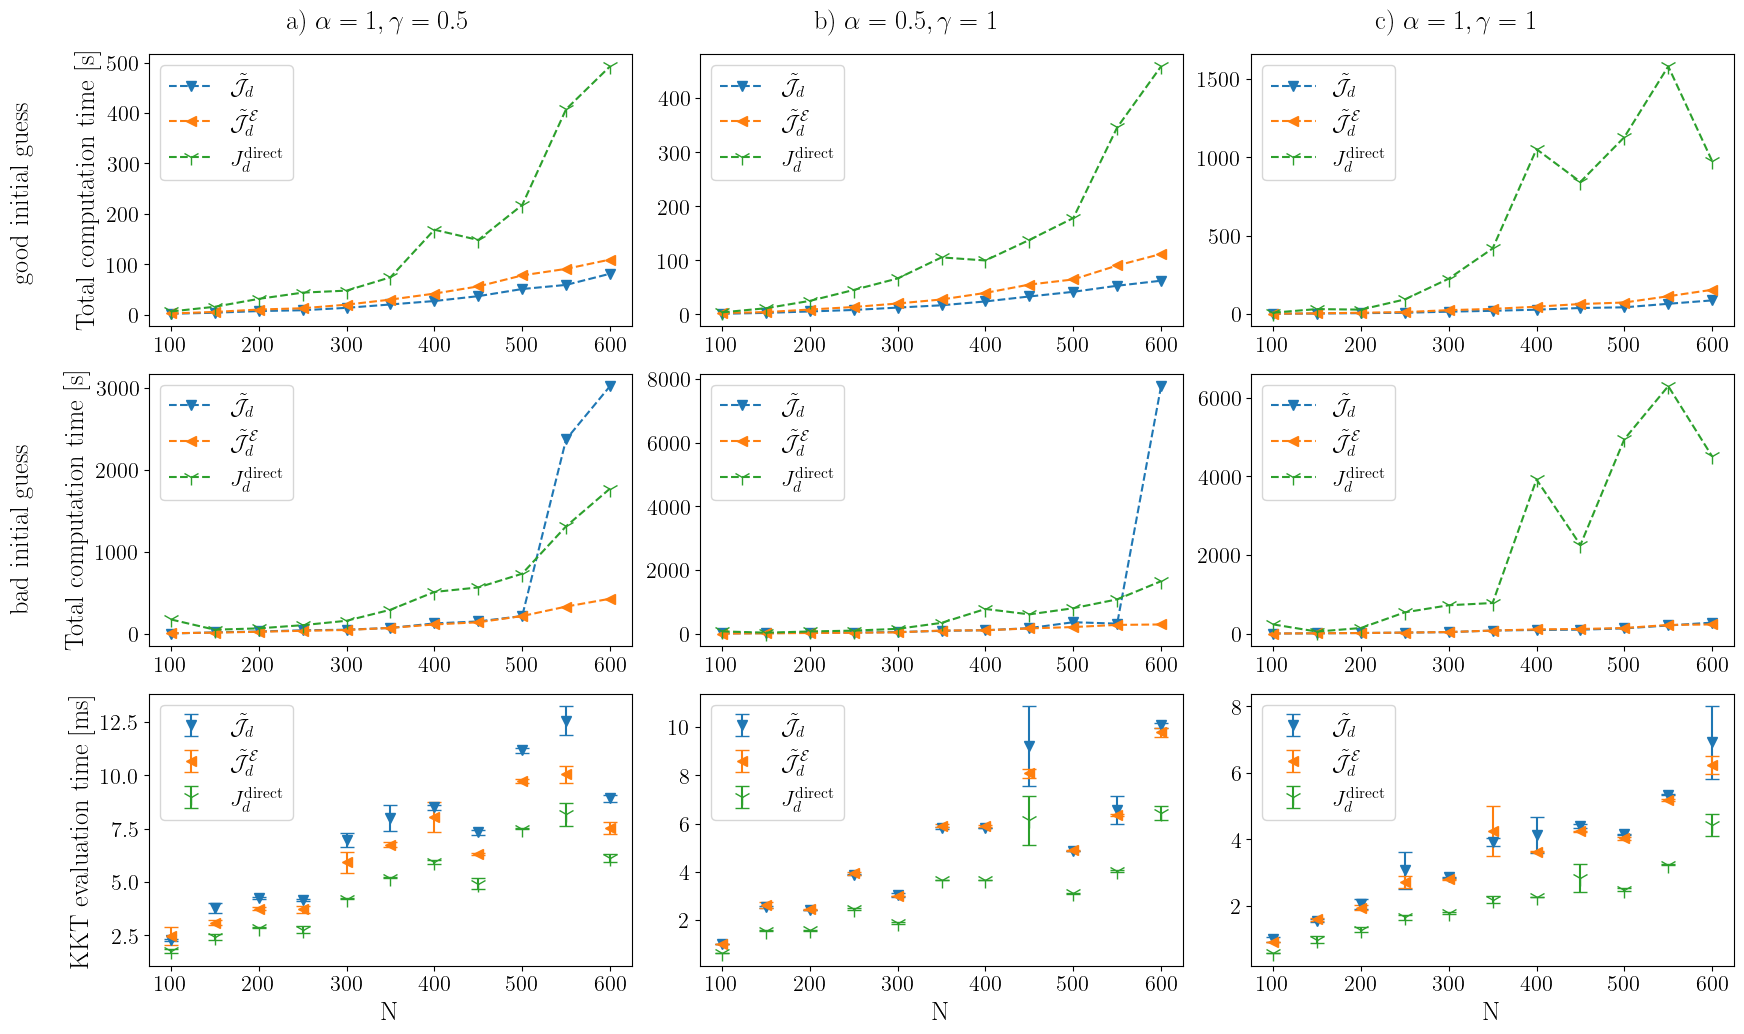

In [15]:
bad_guess_folder = 'data/low_thrust/polar_variables_bad_initial_guess'
data_bad_initial_guess = get_data_from_folder(bad_guess_folder)

labelfont = 19
tickfont = 16
legendfont = 16

alpha_choice = 1
gamma_choice = 0.5
testdata_times = get_run_time_data_from_all(time_data_names,N_choices,data,alpha_choice,gamma_choice)
testdata_times_bad_init = get_run_time_data_from_all(time_data_names,N_choices,data_bad_initial_guess,alpha_choice,gamma_choice)

alpha_choice2 = 0.5
gamma_choice2 = 1
testdata_times2 = get_run_time_data_from_all(time_data_names,N_choices,data,alpha_choice2,gamma_choice2)
testdata_times_bad_init2 = get_run_time_data_from_all(time_data_names,N_choices,data_bad_initial_guess,alpha_choice2,gamma_choice2)

alpha_choice3 = 1
gamma_choice3 = 1
testdata_times3 = get_run_time_data_from_all(time_data_names,N_choices,data,alpha_choice3,gamma_choice3)
testdata_times_bad_init3 = get_run_time_data_from_all(time_data_names,N_choices,data_bad_initial_guess,alpha_choice3,gamma_choice3)

fig,axs = plt.subplots(3,3,figsize=(17, 10))

offset = 3
plot_nr = 0

create_error_plot_choice(N_choices,testdata_times[plot_nr+offset],r"$\tilde{\mathcal{J}}_d$",axs[0][0],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 1
create_error_plot_choice(N_choices,testdata_times[plot_nr+offset],r"$\tilde{\mathcal{J}}_d^\mathcal{E}$",axs[0][0],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 2
create_error_plot_choice(N_choices,testdata_times[plot_nr+offset],r"$J_d^\mathrm{direct}$",axs[0][0],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 0
create_error_plot_choice(N_choices,testdata_times2[plot_nr+offset],r"$\tilde{\mathcal{J}}_d$",axs[0][1],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 1
create_error_plot_choice(N_choices,testdata_times2[plot_nr+offset],r"$\tilde{\mathcal{J}}_d^\mathcal{E}$",axs[0][1],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 2
create_error_plot_choice(N_choices,testdata_times2[plot_nr+offset],r"$J_d^\mathrm{direct}$",axs[0][1],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 0
create_error_plot_choice(N_choices,testdata_times3[plot_nr+offset],r"$\tilde{\mathcal{J}}_d$",axs[0][2],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 1
create_error_plot_choice(N_choices,testdata_times3[plot_nr+offset],r"$\tilde{\mathcal{J}}_d^\mathcal{E}$",axs[0][2],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 2
create_error_plot_choice(N_choices,testdata_times3[plot_nr+offset],r"$J_d^\mathrm{direct}$",axs[0][2],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])



offset = 3
plot_nr = 0

create_error_plot_choice(N_choices,testdata_times_bad_init[plot_nr+offset],r"$\tilde{\mathcal{J}}_d$",axs[1][0],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 1
create_error_plot_choice(N_choices,testdata_times_bad_init[plot_nr+offset],r"$\tilde{\mathcal{J}}_d^\mathcal{E}$",axs[1][0],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 2
create_error_plot_choice(N_choices,testdata_times_bad_init[plot_nr+offset],r"$J_d^\mathrm{direct}$",axs[1][0],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 0
create_error_plot_choice(N_choices,testdata_times_bad_init2[plot_nr+offset],r"$\tilde{\mathcal{J}}_d$",axs[1][1],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 1
create_error_plot_choice(N_choices,testdata_times_bad_init2[plot_nr+offset],r"$\tilde{\mathcal{J}}_d^\mathcal{E}$",axs[1][1],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 2
create_error_plot_choice(N_choices,testdata_times_bad_init2[plot_nr+offset],r"$J_d^\mathrm{direct}$",axs[1][1],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 0
create_error_plot_choice(N_choices,testdata_times_bad_init3[plot_nr+offset],r"$\tilde{\mathcal{J}}_d$",axs[1][2],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 1
create_error_plot_choice(N_choices,testdata_times_bad_init3[plot_nr+offset],r"$\tilde{\mathcal{J}}_d^\mathcal{E}$",axs[1][2],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])
plot_nr = 2
create_error_plot_choice(N_choices,testdata_times_bad_init3[plot_nr+offset],r"$J_d^\mathrm{direct}$",axs[1][2],symbols[plot_nr],symbolsizes[plot_nr],colors[plot_nr])



names = [[r"a) $\alpha=1,\gamma=0.5$",r"b) $\alpha=0.5,\gamma=1$",r"c) $\alpha=1,\gamma=1$"],[r"$\alpha=1,\gamma=0.5$",r"$\alpha=0.5,\gamma=1$",r"$\alpha=1,\gamma=1$"]]
for tmp2,tmpnames2 in zip(axs[0],names[0]):
    tmp2.legend(fontsize=legendfont)
    tmp2.tick_params(which='both',labelsize=tickfont)

plot_data = np.array(single_function_computation_time_plot_dataa1g05)*1e3
plot_nr =0
axs[2][0].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$\tilde{\mathcal{J}}_d$")
plot_nr =1
axs[2][0].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$\tilde{\mathcal{J}}_d^\mathcal{E}$")
plot_nr = 2
axs[2][0].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$J_d^\mathrm{direct}$")

plot_data = np.array(single_function_computation_time_plot_dataa05g1)*1e3
plot_nr =0
axs[2][1].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$\tilde{\mathcal{J}}_d$")
plot_nr =1
axs[2][1].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$\tilde{\mathcal{J}}_d^\mathcal{E}$")
plot_nr = 2
axs[2][1].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$J_d^\mathrm{direct}$")


plot_data = np.array(single_function_computation_time_plot_dataa1g1)*1e3
plot_nr =0
axs[2][2].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$\tilde{\mathcal{J}}_d$")
plot_nr =1
axs[2][2].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$\tilde{\mathcal{J}}_d^\mathcal{E}$")
plot_nr = 2
axs[2][2].errorbar(N_choices, plot_data[plot_nr][:,0],capsize=5,yerr=plot_data[plot_nr][:,1],marker=symbols[plot_nr],markersize=symbolsizes[plot_nr],color=colors[plot_nr],linestyle='None',label=r"$J_d^\mathrm{direct}$")


axs[0][0].set_ylabel(r'Total computation time [s]',fontsize=labelfont)
axs[1][0].set_ylabel(r'Total computation time [s]',fontsize=labelfont)
axs[2][0].set_ylabel('KKT evaluation time [ms]',fontsize=labelfont)

for tmp in axs[-1]:
    tmp.set_xlabel('N',fontsize=labelfont)


for axs_tmp in axs:
    for tmp2,tmpnames2 in zip(axs_tmp,names[0]):
        tmp2.legend(title_fontsize=legendfont,fontsize=legendfont)
        tmp2.tick_params(which='both',labelsize=tickfont)



  
fig.text(0.14,1.01,names[0][0],fontsize=labelfont)
fig.text(0.45,1.01,names[0][1],fontsize=labelfont)
fig.text(0.78,1.01,names[0][2],fontsize=labelfont)


plt.tight_layout()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())
x0,y0,width,height = bbox.transformed(fig.transFigure.inverted()).bounds

ypad=20.5*height
width = 101*width
height=1.3*30*height
xpad=0*width
fig.text(-0.023,0.76,r'good initial guess',rotation='vertical',fontsize=labelfont)
fig.text(-0.023,0.43,r'bad initial guess',rotation='vertical',fontsize=labelfont)

# plt.savefig('Total_time_comparison_full.pdf',bbox_inches='tight',edgecolor=fig.get_edgecolor())


# Plotting of n-satellite data

In [16]:
base_folder_dir = 'data/n_low_thrust/polar_variables'

n_satellite_data=get_data_from_folder(base_folder_dir)

n_satellite_plotting_data = n_satellite_data['data_a=1g=0.5N=200.pkl'][0]


Text(-0.0051, 0.41, 'costate variables')

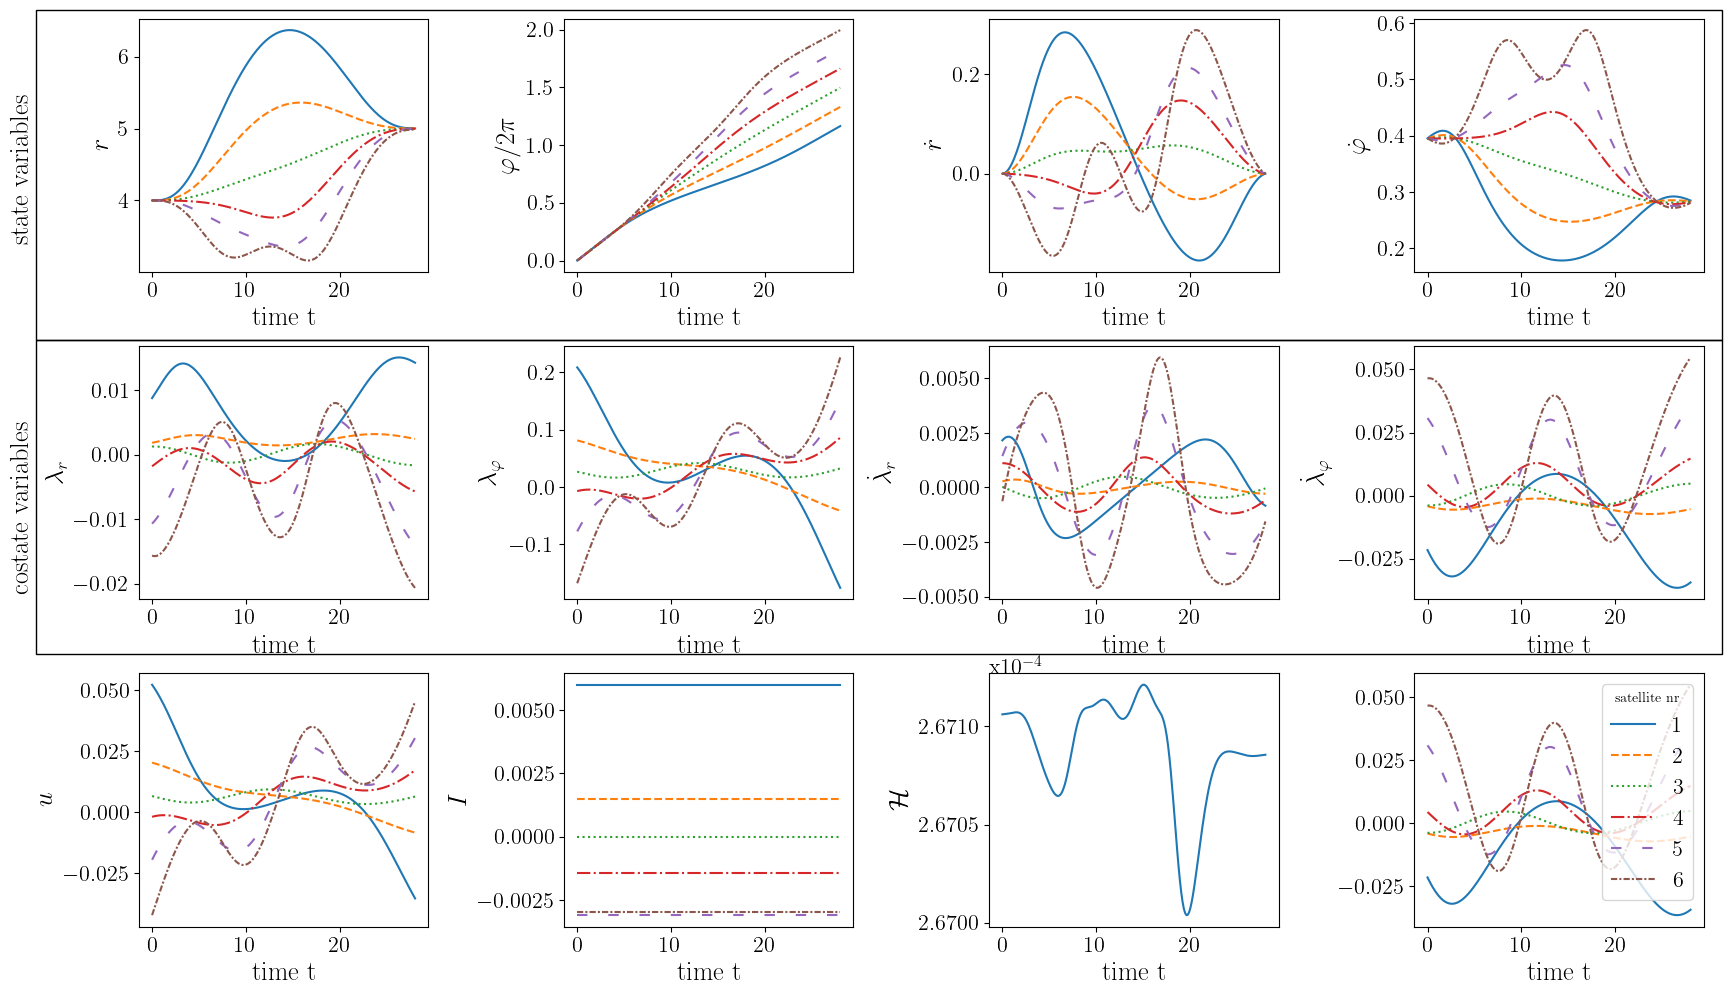

In [17]:

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','C4','C5','C6']
symbols = ['solid','dashed','dotted','dashdot', (0,(5,10)),(0,(3,1,1,1))]
nr_satellites = n_satellite_plotting_data['parameters']['n_satellites']

fig=plt.figure(figsize=(17, 10))
axs = [[],[],[]]

for i in range(4):
    for j in range(3):
        axs[j].append(plt.subplot(3,4,1+i+4*j))

tvals=n_satellite_plotting_data['parameters']['times']
for n in range(nr_satellites):
    axs[0][0].plot(tvals,n_satellite_plotting_data['q_d_new'].T[2*n],ls=symbols[n],color=colors[n],label=str(n+1))
    axs[0][1].plot(tvals,n_satellite_plotting_data['q_d_new'].T[2*n+1]/(2*np.pi),ls=symbols[n],color=colors[n],label=str(n+1))
    axs[0][2].plot(tvals,n_satellite_plotting_data['v_y_d_new'].T[2*n],ls=symbols[n],color=colors[n],label=str(n+1))
    axs[0][3].plot(tvals,n_satellite_plotting_data['v_y_d_new'].T[2*n+1],ls=symbols[n],color=colors[n],label=str(n+1))
    axs[1][0].plot(tvals,n_satellite_plotting_data['lambda_d_new'].T[2*n],ls=symbols[n],color=colors[n],label=str(n+1))
    axs[1][1].plot(tvals,n_satellite_plotting_data['lambda_d_new'].T[2*n+1],ls=symbols[n],color=colors[n],label=str(n+1))
    axs[1][2].plot(tvals,n_satellite_plotting_data['v_y_d_new'].T[2*nr_satellites+2*n],ls=symbols[n],color=colors[n],label=str(n+1))
    axs[1][3].plot(tvals,n_satellite_plotting_data['v_y_d_new'].T[2*nr_satellites+2*n+1],ls=symbols[n],color=colors[n],label=str(n+1))    
    axs[2][0].plot(tvals,n_satellite_plotting_data['u_d_new'].T[n],ls=symbols[n],color=colors[n],label=str(n+1))    
    axs[2][1].plot(tvals,n_satellite_plotting_data['I_d_new'][n],ls=symbols[n],color=colors[n],label=str(n+1))    
    axs[2][3].plot(tvals,n_satellite_plotting_data['v_y_d_new'].T[2*nr_satellites+2*n+1],ls=symbols[n],color=colors[n],label=str(n+1))    

axs[2][2].plot(tvals,(-np.array(n_satellite_plotting_data['H_control_new'])).T*1000,ls=symbols[0],color=colors[0])    

axs[0][0].set_ylabel(r'$r$',fontsize=labelfont)
axs[0][1].set_ylabel(r'$\varphi/2\pi$',fontsize=labelfont)
axs[0][2].set_ylabel(r'$\dot{r}$',fontsize=labelfont)
axs[0][3].set_ylabel(r'$\dot{\varphi}$',fontsize=labelfont)
axs[1][0].set_ylabel(r'$\lambda_r$',fontsize=labelfont)
axs[1][1].set_ylabel(r'$\lambda_{\varphi}$',fontsize=labelfont)
axs[1][2].set_ylabel(r'$\dot{\lambda}_r$',fontsize=labelfont)
axs[1][3].set_ylabel(r'$\dot{\lambda}_\varphi$',fontsize=labelfont)
axs[2][0].set_ylabel(r'$u$',fontsize=labelfont)
axs[2][1].set_ylabel(r'$I$',fontsize=labelfont)
axs[2][2].set_ylabel(r'${\mathcal{H}}$',fontsize=labelfont)

fig.text(0.571,0.326,r'x$10^{-4}$',fontsize=tickfont)

for tmp1 in axs: 
    for tmp2 in tmp1:
        tmp2.set_xlabel('time t',fontsize=labelfont)
        tmp2.tick_params(labelsize=tickfont)


import matplotlib.ticker
axs[2][3].legend(title='satellite nr',fontsize=legendfont)
fig.tight_layout()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())
x0,y0,width,height = bbox.transformed(fig.transFigure.inverted()).bounds
ypad=31.8*1.122*height

width = 101*width
height=32.4*height
xpad=0.01*width
fig.add_artist(plt.Rectangle((x0+xpad,y0+ypad+height),width,1.05*(height),edgecolor='black',linewidth=1,fill=False))
fig.add_artist(plt.Rectangle((x0+xpad,y0+ypad),width,(height),edgecolor='black',linewidth=1,fill=False))
fig.text(-0.0051,0.76,r'state variables',rotation='vertical',fontsize=labelfont)
fig.text(-0.0051,0.41,r'costate variables',rotation='vertical',fontsize=labelfont)


# plt.savefig('n_satellite_illustration.pdf',bbox_inches='tight',edgecolor=fig.get_edgecolor())

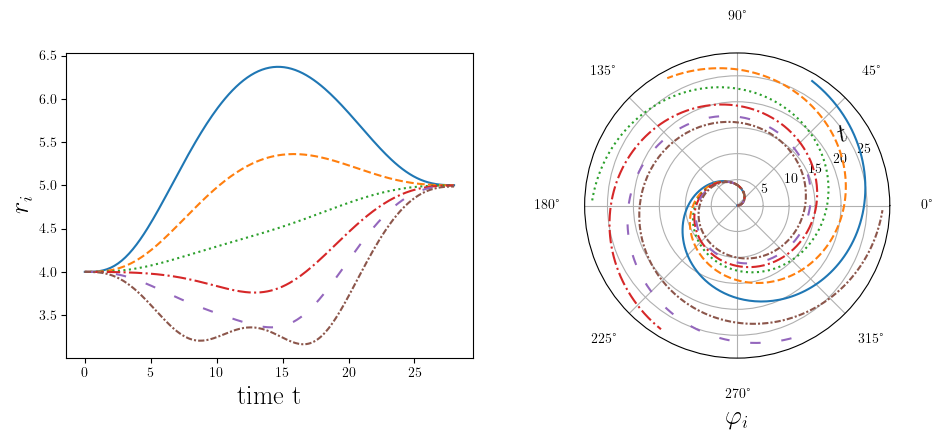

In [18]:

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','C4','C5','C6']
symbols = ['solid','dashed','dotted','dashdot', (0,(5,10)),(0,(3,1,1,1))]
nr_satellites = n_satellite_plotting_data['parameters']['n_satellites']

fig=plt.figure(figsize=(10, 4.5))
axs =[]

axs.append(plt.subplot(1,2,2,projection='polar'))
axs.append(plt.subplot(1,2,1))
tvals=n_satellite_plotting_data['parameters']['times']
for n in range(nr_satellites):
    axs[0].plot(n_satellite_plotting_data['q_d_new'].T[2*n+1],tvals,ls=symbols[n],color=colors[n],label=str(n+1))
    axs[1].plot(tvals, (n_satellite_plotting_data['q_d_new'].T[2*n]),ls=symbols[n],color=colors[n],label=str(n+1))
axs[0].set_xlabel(r'$\Delta \varphi_i$',fontsize=labelfont)
axs[0].set_xlabel(r'$\varphi_i$',fontsize=labelfont)
axs[0].tick_params(bottom=False,size=tickfont)
label_position=axs[0].get_rlabel_position()
axs[0].text(np.radians(label_position*1.5),axs[0].get_rmax()/1.2,r'$t$',rotation=label_position,ha='center',va='center',fontsize=labelfont)
axs[1].set_xlabel('time t',fontsize=labelfont)
axs[1].set_ylabel(r'$\Delta r_i$',fontsize=labelfont)
axs[1].set_ylabel(r'$r_i$',fontsize=labelfont)
plt.tight_layout()

# plt.savefig('n_satellite_polar_illustration.pdf',bbox_inches='tight',edgecolor=fig.get_edgecolor())